# **Comparative Analysis on ACDC**

This notebook compares the preliminary in-domain results obtained with YOLOv11 and Faster R-CNN on the ACDC dataset.


Objectives:
*   Compare overall detection performance
*   Compare weather-specific performance

*   Visualize the speed-accuracy trade-off
*  Prepare tables and figures for the dissertation


### Connect to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Imports librairies

In [3]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Define paths

In [4]:
BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Dissertation")

YOLO_RUN_DIR = BASE_DIR / "Runs/yolo/acdc_in_domain_yolo11s_seed42"

FRCNN_RUN_DIR = BASE_DIR / "Runs/faster_rcnn/acdc_in_domain_faster_rcnn_seed42"

YOLO_WEATHER_JSON = YOLO_RUN_DIR / "acdc_yolo11s_in_domain_results_summary.json"

FRCNN_RESULTS_JSON = FRCNN_RUN_DIR / "acdc_faster_rcnn_in_domain_results_summary.json"

COMPARISON_DIR = BASE_DIR / "Runs/comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)


print("YOLO JSON exists:", YOLO_WEATHER_JSON.exists())
print("Faster R-CNN JSON exists:", FRCNN_RESULTS_JSON.exists())
print("Comparison output:", COMPARISON_DIR)

YOLO JSON exists: True
Faster R-CNN JSON exists: True
Comparison output: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42


In [5]:
csv_path = COMPARISON_DIR / "acdc_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv"

json_path = COMPARISON_DIR / "acdc_indomain_yolo_vs_fasterrcnn_seed42_comparison.json"

# **Load Results**

In [6]:
#YOLO results

with open(YOLO_WEATHER_JSON, "r") as f:
    yolo_results = json.load(f)

yolo_results = pd.DataFrame(yolo_results)

print(yolo_results)

  dataset     model experiment  seed condition  mAP50-95     mAP50     mAP75  \
0    ACDC  YOLOv11s  in_domain    42    global  0.332924  0.521167  0.345546   
1    ACDC  YOLOv11s  in_domain    42       fog  0.412664  0.627669  0.427248   
2    ACDC  YOLOv11s  in_domain    42      rain  0.308140  0.483562  0.319447   
3    ACDC  YOLOv11s  in_domain    42      snow  0.355982  0.559802  0.364799   

   Precision    Recall  F1-score  Inference_ms_per_image        FPS  
0   0.765000  0.441276  0.559700               11.829795  84.532316  
1   0.858360  0.546958  0.668158               11.745399  85.139722  
2   0.766111  0.405806  0.530571               11.654375  85.804685  
3   0.724260  0.460557  0.563062               11.945242  83.715342  


In [7]:
#Faster R-CNN results

with open(FRCNN_RESULTS_JSON, "r") as f:
    frcnn_results = json.load(f)

frcnn_results = pd.DataFrame(frcnn_results)

print(frcnn_results)

  dataset         model experiment  seed condition  mAP50-95     mAP50  \
0    ACDC  Faster R-CNN  in_domain    42    global  0.412798  0.596349   
1    ACDC  Faster R-CNN  in_domain    42       fog  0.547244  0.754025   
2    ACDC  Faster R-CNN  in_domain    42      rain  0.363072  0.526218   
3    ACDC  Faster R-CNN  in_domain    42      snow  0.488865  0.695103   

      mAP75  Inference_ms_per_image        FPS  
0  0.449924               62.100221  16.103002  
1  0.590740               61.857751  16.166123  
2  0.397296               61.891234  16.157377  
3  0.527242               61.898735  16.155419  


# **Comparison table**

In [8]:
rows = []

# YOLO results
for _, row in yolo_results.iterrows():
    rows.append({
        "split": row["condition"],
        "model": "YOLOv11s",

        "mAP50-95": row["mAP50-95"],
        "mAP50": row["mAP50"],
        "mAP75": row["mAP75"],

        "Precision": row["Precision"],
        "Recall": row["Recall"],

        "F1-score": row["F1-score"],
        "mAR100": np.nan,

        "FPS": row["FPS"]
    })


# Faster R-CNN results
for _, row in frcnn_results.iterrows():
    rows.append({
        "split": row["condition"],
        "model": "Faster R-CNN",

        "mAP50-95": row["mAP50-95"],
        "mAP50": row["mAP50"],
        "mAP75": row["mAP75"],

        "Precision": np.nan,
        "Recall": np.nan,

        "F1-score": np.nan,
        "mAR100": row.get("mAR100", np.nan),

        "FPS": row["FPS"]
    })


comparison_df = pd.DataFrame(rows)

split_order = ["global", "fog", "rain", "snow"]
model_order = ["YOLOv11s", "Faster R-CNN"]

comparison_df["split"] = pd.Categorical(
    comparison_df["split"],
    categories=split_order,
    ordered=True
)

comparison_df["model"] = pd.Categorical(
    comparison_df["model"],
    categories=model_order,
    ordered=True
)

comparison_df = comparison_df.sort_values(
    ["split", "model"]
).reset_index(drop=True)

comparison_df

,split,model,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,mAR100,FPS
0,global,YOLOv11s,0.332924,0.521167,0.345546,0.765000,0.441276,0.559700,NaN,84.532316
1,global,Faster R-CNN,0.412798,0.596349,0.449924,NaN,NaN,NaN,NaN,16.103002
2,fog,YOLOv11s,0.412664,0.627669,0.427248,0.858360,0.546958,0.668158,NaN,85.139722
3,fog,Faster R-CNN,0.547244,0.754025,0.590740,NaN,NaN,NaN,NaN,16.166123
4,rain,YOLOv11s,0.308140,0.483562,0.319447,0.766111,0.405806,0.530571,NaN,85.804685
5,rain,Faster R-CNN,0.363072,0.526218,0.397296,NaN,NaN,NaN,NaN,16.157377
6,snow,YOLOv11s,0.355982,0.559802,0.364799,0.724260,0.460557,0.563062,NaN,83.715342
7,snow,Faster R-CNN,0.488865,0.695103,0.527242,NaN,NaN,NaN,NaN,16.155419


### **Save Comparison Table**

In [ ]:
comparison_df.to_csv(csv_path, index=False)

comparison_df.to_json(
    json_path,
    orient="records",
    indent=4
)

print("Comparison files saved.")


Comparison files saved.


In [ ]:
print("CSV:", csv_path)
print("JSON:", json_path)

CSV: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42/acdc_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv
JSON: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42/acdc_indomain_yolo_vs_fasterrcnn_seed42_comparison.json


# **Visualisation**

In [9]:
def grouped_bar_plot(df, metric, title, ylabel, output_name):
    plot_df = df[["split", "model", metric]].dropna()

    pivot_df = plot_df.pivot(index="split", columns="model", values=metric)

    split_order = ["global", "fog", "rain", "snow"]
    pivot_df = pivot_df.loc[[s for s in split_order if s in pivot_df.index]]

    ax = pivot_df.plot(kind="bar", figsize=(9, 5))

    ax.set_title(title)
    ax.set_xlabel("Evaluation split")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(1.0, pivot_df.max().max() + 0.1))
    ax.legend(title="Model")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.xticks(rotation=0)
    plt.tight_layout()

    output_path = COMPARISON_DIR / output_name
    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Saved:", output_path)

### Plot mAP50-95

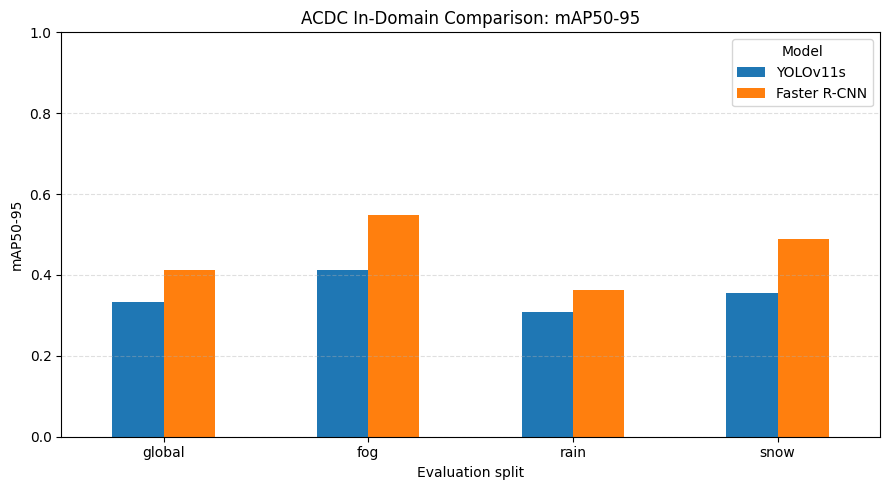

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42/map50_95_comparison.png


In [10]:
grouped_bar_plot(
    comparison_df,
    metric="mAP50-95",
    title="ACDC In-Domain Comparison: mAP50-95",
    ylabel="mAP50-95",
    output_name="map50_95_comparison.png"
)

### Plot mAP50

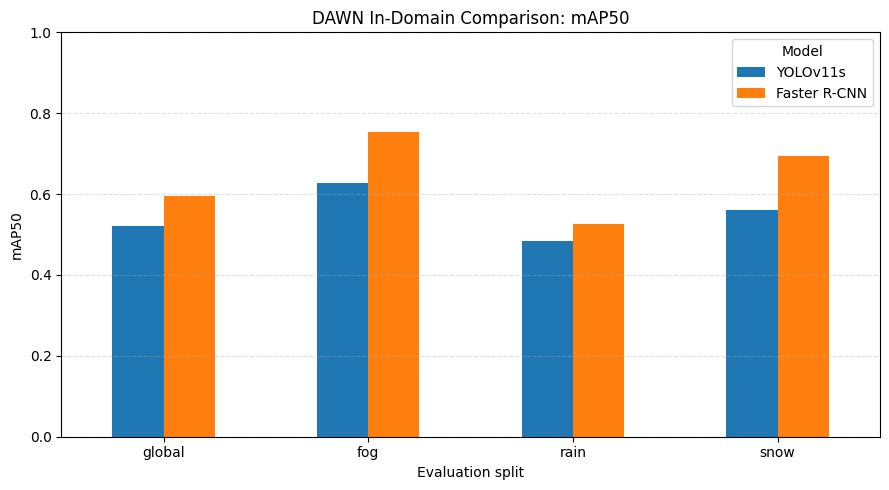

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42/map50_comparison.png


In [ ]:
grouped_bar_plot(
    comparison_df,
    metric="mAP50",
    title="DAWN In-Domain Comparison: mAP50",
    ylabel="mAP50",
    output_name="map50_comparison.png"
)

### Plot FPS

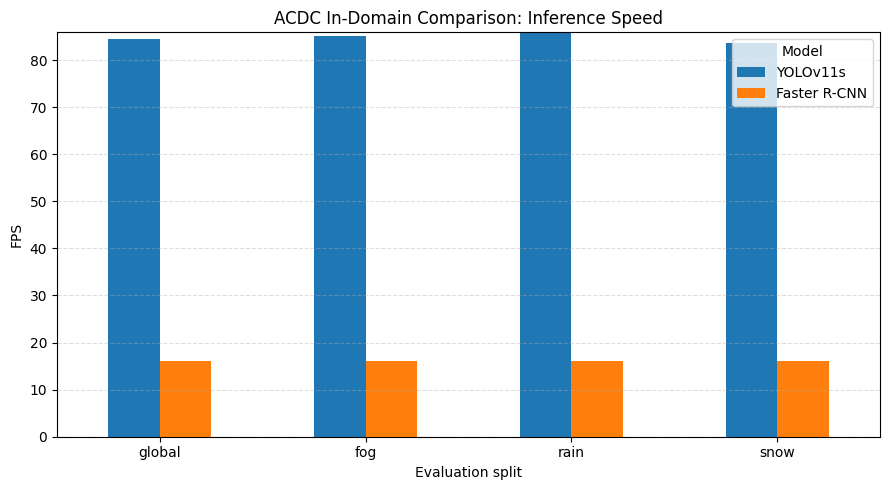

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42/fps_comparison.png


In [11]:
grouped_bar_plot(
    comparison_df,
    metric="FPS",
    title="ACDC In-Domain Comparison: Inference Speed",
    ylabel="FPS",
    output_name="fps_comparison.png"
)